<a href="https://colab.research.google.com/github/Pooja29102920/ML/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [5]:
from google.colab import files

uploaded = files.upload()

Saving binary.csv to binary.csv


In [6]:
data=pd.read_csv('/content/binary.csv')

In [9]:
col_names = ['admit', 'gre', 'gpa', 'rank']
data.columns = col_names
print(data.shape)
data.head()

(400, 4)


,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [11]:
data.isnull().sum()

,0
admit,0
gre,0
gpa,0
rank,0


In [12]:
feature_cols = ['gre', 'gpa', 'rank']
x = data[feature_cols]
y = data['admit']

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=5
)
display(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(320, 3)

(320,)

(80, 3)

(80,)

In [17]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)

In [18]:
model.fit(x_train, y_train)
y_pred=model.predict(x_test)

In [19]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_mat)
accuracy_score = metrics.accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy_score)
print("Accuracy in Percentage:", round(accuracy_score * 100, 2), "%")

Confusion Matrix:
[[50  4]
 [23  3]]
Accuracy Score: 0.6625
Accuracy in Percentage: 66.25 %


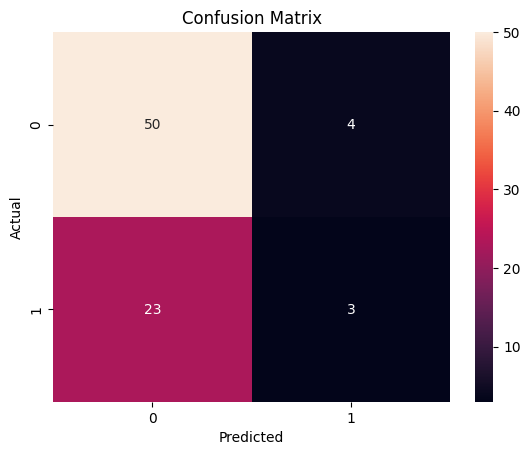

In [26]:
conf_mat = pd.crosstab(y_test, y_pred,
                       rownames=['Actual'],
                       colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()